# 01 — Exploratory Data Analysis
**Amreen | Predictive Asset Health MLOps**

Before touching a model I want to understand what the data is actually telling me.
Key questions:
- How many engines, how long do they run?
- Which sensors carry useful signal vs. which ones are flat?
- What does degradation actually look like in this data?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

In [2]:
import sys, os
sys.path.insert(0, '..')

from src.ingestion.load_data import load_train, load_test
from src.ingestion.validate  import validate, assert_valid

train = load_train(data_dir='../data/raw')
test, rul_df = load_test(data_dir='../data/raw')

print(f"Train  : {train.shape}")
print(f"Test   : {test.shape}")
print(f"RUL ref: {rul_df.shape}")

Train  : (19134, 26)
Test   : (3086, 26)
RUL ref: (20, 2)


In [3]:
# Quick validation pass before anything else
issues = validate(train)
for cat, msgs in issues.items():
    if msgs:
        print(f"[{cat.upper()}]")
        for m in msgs: print(f"  {m}")
    else:
        print(f"[{cat.upper()}] OK")

[SCHEMA] OK
[MISSING] OK
[RANGES] OK
[CYCLES] OK


## Engine lifetime distribution

Number of engines : 80
Min lifetime      : 130 cycles
Max lifetime      : 344 cycles
Mean lifetime     : 239.2 cycles
Std               : 62.8 cycles


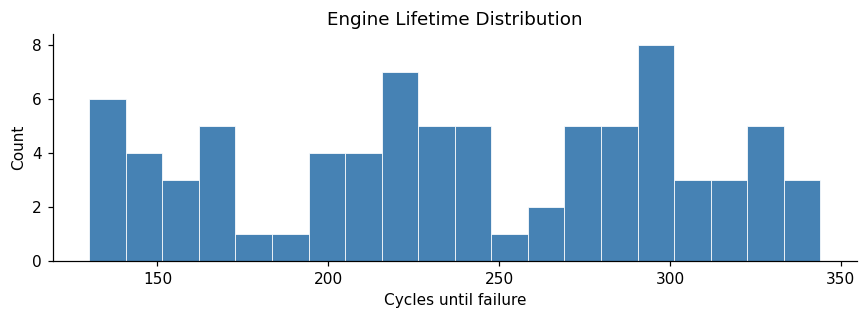

In [4]:
lifetimes = train.groupby('unit_id')['cycle'].max()
print(f"Number of engines : {len(lifetimes)}")
print(f"Min lifetime      : {lifetimes.min()} cycles")
print(f"Max lifetime      : {lifetimes.max()} cycles")
print(f"Mean lifetime     : {lifetimes.mean():.1f} cycles")
print(f"Std               : {lifetimes.std():.1f} cycles")

fig, ax = plt.subplots(figsize=(8,3))
ax.hist(lifetimes, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Cycles until failure')
ax.set_ylabel('Count')
ax.set_title('Engine Lifetime Distribution')
plt.tight_layout()
plt.show()

## Sensor variance — finding the flat ones

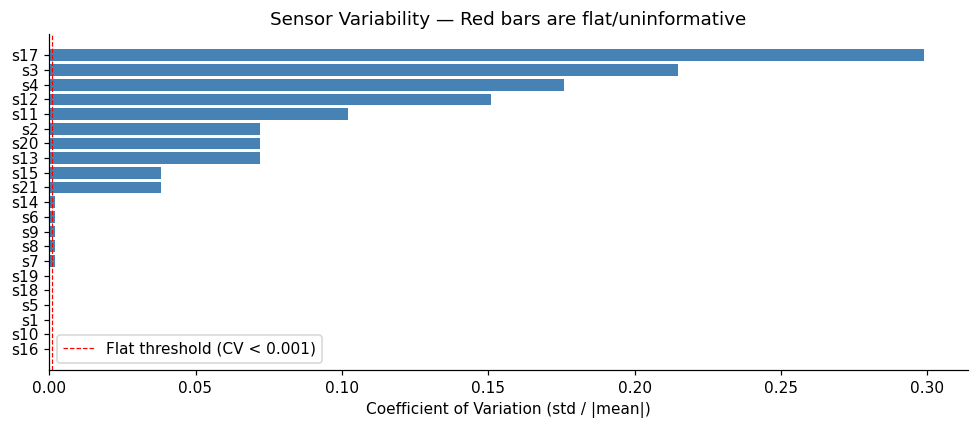

Flat sensors to drop: ['s16', 's10', 's1', 's5', 's18', 's19']


In [5]:
SENSOR_COLS = [f's{i}' for i in range(1, 22)]

# coefficient of variation per sensor (std/mean)
cv = (train[SENSOR_COLS].std() / train[SENSOR_COLS].mean().abs()).sort_values()

fig, ax = plt.subplots(figsize=(9,4))
bars = ax.barh(cv.index, cv.values, color=['#e74c3c' if v < 0.001 else 'steelblue' for v in cv.values])
ax.axvline(0.001, color='red', linestyle='--', linewidth=0.8, label='Flat threshold (CV < 0.001)')
ax.set_xlabel('Coefficient of Variation (std / |mean|)')
ax.set_title('Sensor Variability — Red bars are flat/uninformative')
ax.legend()
plt.tight_layout()
plt.show()

flat = cv[cv < 0.001].index.tolist()
print(f"Flat sensors to drop: {flat}")

## Degradation curves — what failure looks like

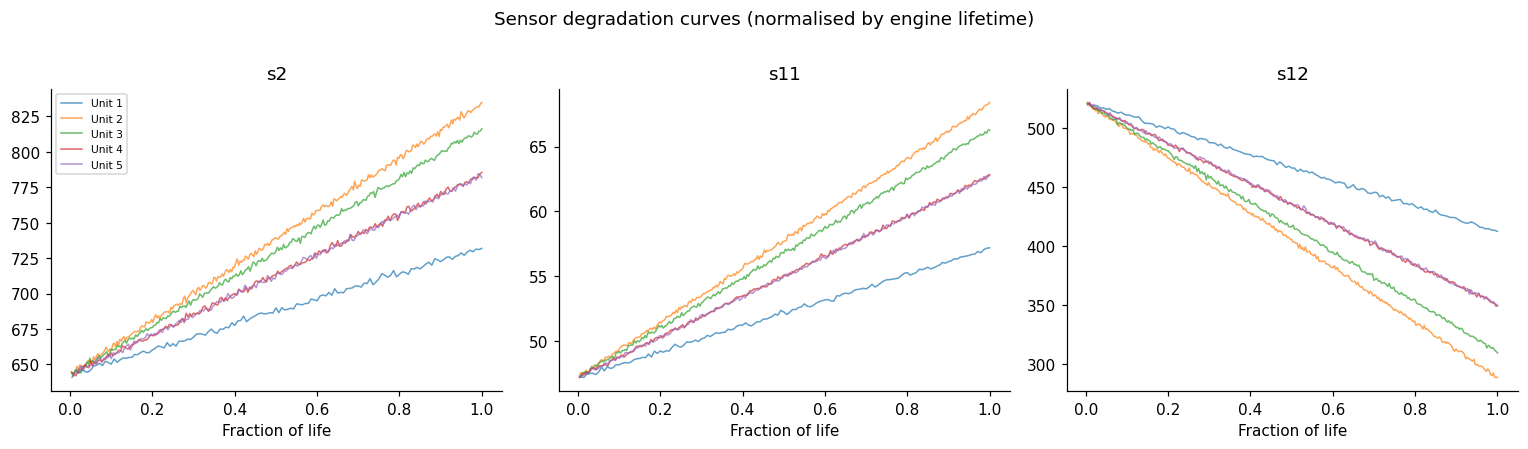

In [6]:
# pick 3 informative sensors and plot degradation for 5 sample engines
sample_units = train['unit_id'].unique()[:5]
sensors_to_plot = ['s2', 's11', 's12']

fig, axes = plt.subplots(1, 3, figsize=(14,4), sharey=False)
colors = plt.cm.tab10.colors

for ax, sensor in zip(axes, sensors_to_plot):
    for i, uid in enumerate(sample_units):
        unit_data = train[train['unit_id'] == uid].sort_values('cycle')
        max_cyc   = unit_data['cycle'].max()
        # normalise x-axis to fraction of life
        ax.plot(unit_data['cycle'] / max_cyc,
                unit_data[sensor],
                alpha=0.7, color=colors[i], linewidth=1.0,
                label=f'Unit {uid}')
    ax.set_xlabel('Fraction of life')
    ax.set_title(sensor)
    if ax == axes[0]:
        ax.legend(fontsize=7)

fig.suptitle('Sensor degradation curves (normalised by engine lifetime)', y=1.01)
plt.tight_layout()
plt.show()

## Takeaways
- **Flat sensors** (CV < 0.001): s1, s5, s10, s16, s18, s19 — drop these in feature engineering
- Degradation is **gradual and noisy** — raw sensor values alone won't be enough; rolling features and slopes will help
- Engine lifetimes are fairly spread (120–350 cycles) which is good for RUL regression
- No critical missing values or range violations in this dataset
